In [1]:
import pandas as pd
import numpy as np

from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error
BASE_DIR = Path("C:/Users/VSB-AIDSPC20/Downloads/demand forecating")
DATA_DIR = BASE_DIR / "data" / "processed"

train = pd.read_csv(DATA_DIR / "train_features.csv", parse_dates=["date"])
valid = pd.read_csv(DATA_DIR / "valid_features.csv", parse_dates=["date"])

train.shape, valid.shape



((716500, 20), (182500, 20))

In [2]:
X_train = train.drop(columns=["sales", "date"])
y_train = train["sales"]

X_valid = valid.drop(columns=["sales", "date"])
y_valid = valid["sales"]


In [3]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_preds = rf.predict(X_valid)

mae_rf = mean_absolute_error(y_valid, rf_preds)
rmse_rf = np.sqrt(mean_squared_error(y_valid, rf_preds))

mae_rf, rmse_rf


(6.525168667956781, np.float64(8.549515547651023))

In [5]:
!pip install xgboost


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.8/72.0 MB 6.7 MB/s eta 0:00:11
   -- ------------------------------------- 4.7/72.0 MB 15.0 MB/s eta 0:00:05
   --------- ------------------------------ 17.8/72.0 MB 34.0 MB/s eta 0:00:02
   ----------------- ---------------------- 31.2/72.0 MB 42.1 MB/s eta 0:00:01
   ------------------------ --------------- 44.3/72.0 MB 47.0 MB/s eta 0:00:01
   ------------------------------- -------- 56.9/72.0 MB 48.9 MB/s eta 0:00:01
   -------------------------------------- - 70.0/72.0 MB 50.7 MB/s eta 0:00:01
   ---------------------------------------- 72.0/72.0 MB 46.4 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\VSB-AIDSPC20\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [6]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_valid)

mae_xgb = mean_absolute_error(y_valid, xgb_preds)
rmse_xgb = np.sqrt(mean_squared_error(y_valid, xgb_preds))

mae_xgb, rmse_xgb


(6.104461669921875, np.float64(7.928608878303759))

In [8]:
results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        mae_rf,
        mae_xgb
    ],
    "RMSE": [
        rmse_rf,
        rmse_xgb
    ]
})

results.sort_values("MAE")


,Model,MAE,RMSE
1,XGBoost,6.104462,7.928609
0,Random Forest,6.525169,8.549516


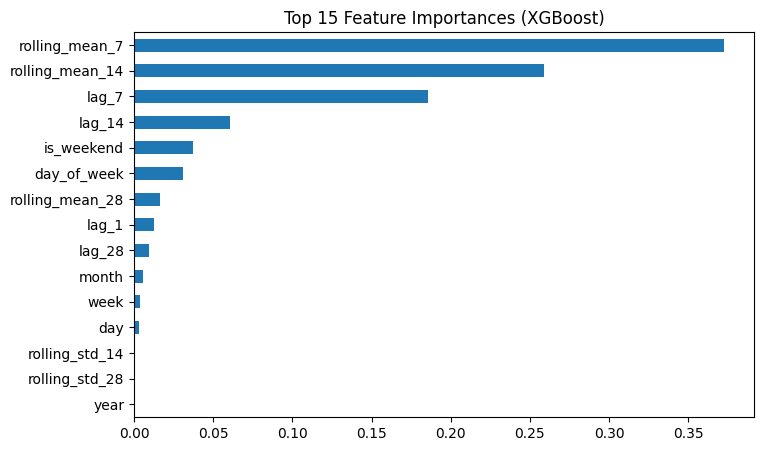

In [9]:
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)[:15]

plt.figure(figsize=(8,5))
feature_importance.plot(kind="barh")
plt.title("Top 15 Feature Importances (XGBoost)")
plt.gca().invert_yaxis()
plt.show()
